# Preamble

In [1]:
try:
    print_spark_info()
except:
    %run ../spark-instance.ipynb

SparkConf created
Started SparkSession
Spark version 3.5.3
You should be able to access the Spark UI at: https://dacs-compute-gate.ewi.utwente.nl:9999/user/g.luvizottocesar@utwente.nl/proxy/4040/stages/
Note that you may have to Enable extensions first via the Extension Manager.


In [7]:
#clean_spark()

CLEANING SPARK INSTANCE...


In [2]:
from datetime import datetime
import math

# installed pkg imports
import numpy as np
import pandas as pd
import logging
import dns.message
import binascii

# pyspark related imports
import pyspark.sql.types as pst
from pyspark.sql import functions as psf
from pyspark.sql.window import Window
from functools import reduce
import matplotlib.ticker as mticker

import matplotlib.pyplot as plt
from og_ntplib import NTPPacket

from lzr_port_handshake import lzr_port_hs_map, EPHEMERAL_START, IANA_HS, EPHEMERAL_HS

spark.sparkContext.addPyFile("/home/sparky/data/anycast-service-discovery/og_ntplib.py")

In [3]:
# Create logger
logger = logging.getLogger("anycast")
logger.setLevel(logging.INFO)

# Prevent duplicate logs if logger already has handlers
if not logger.handlers:
    # Create file handler
    file_handler = logging.FileHandler("logs.log", encoding='utf-8')
    file_handler.setLevel(logging.INFO)
    
    # Create formatter
    formatter = logging.Formatter(
        fmt='%(asctime)s %(levelname)-8s %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    )
    
    # Add formatter to handler
    file_handler.setFormatter(formatter)
    
    # Add handler to logger
    logger.addHandler(file_handler)
else:
    print("logger already exist!")

# Optionally, prevent propagation to root logger to avoid duplicates
logger.propagate = False

In [4]:
def is_ntp(d):
    raw = binascii.unhexlify(d)
    # https://en.wikipedia.org/wiki/Network_Time_Protocol
    # len(raw) is 48 typically...
    pkt = NTPPacket()
    try:
        pkt.from_data(raw)
        if (0 <= pkt.version <= 4) and (0 <= pkt.mode <= 7):
            return True
        else:
            return False
    except:
        return False


def is_dns(d):
    raw = binascii.unhexlify(d)
    try:
        dns.message.from_wire(raw)
        return True
    except:
        return False


def get_dns_data(d):
    raw = binascii.unhexlify(d)
    try:
        return str(dns.message.from_wire(raw))
    except:
        return None


with open("initial_qscanner_1a1a1a1a.pkt", "rb") as initial_file:
    _sent = bytearray(initial_file.read())
broadcast_sent = spark.sparkContext.broadcast(_sent)


def is_quic(data, saddr, sent):
    # adapted from https://github.com/quic-hunter/libraries/blob/main/identification/zmap_classification_scale.py
    def conn_id_match(left: bytearray, left_start: int, right: bytearray, right_start: int):
        # Compare two connection IDs starting at their length fields
        if left_start >= len(left) or right_start >= len(right):
            return False
        
        # check if lengths match
        if left[left_start] != right[right_start]:
            return False
        
        # check each byte of ID
        for i in range(left[left_start]):
            if (left_start + i + 1) >= len(left) or (right_start + i + 1) >= len(right):
                return False
            if left[left_start + i + 1] != right[right_start + i + 1]:
                return False
    
        return True

    # QUIC Initial fixed bits and mask
    initial_header = 0b11000000
    initial_header_mask = 0b11000000
    
    # QUIC Version Negotiation fixed bits and mask
    vn_header = 0b10000000
    vn_header_mask = 0b10000000
    if not isinstance(data, str):
        return False

    recv = bytearray.fromhex(data)

    if len(recv) < 6 or len(sent) < 6:
        return False

    sent_src_id_start = 5 + sent[5] + 1
    recv_src_id_start = 5 + recv[5] + 1
    
    # Version Negotiation packet: match header and version
    if (vn_header & vn_header_mask) == (recv[0] & vn_header_mask) and (recv[1:5] == bytearray.fromhex("00000000")):

        # Check if src and dest connection IDs are as expected
        if conn_id_match(sent, sent_src_id_start, recv, 5) and conn_id_match(sent, 5, recv, recv_src_id_start):
            if len(recv) <= recv_src_id_start:
               return False # [saddr, "quic-vn-err-short", 0, ""]
         
            # extract versions
            recv_versions_start = recv_src_id_start + recv[recv_src_id_start] + 1
            versions_len = len(recv) - recv_versions_start
            if versions_len % 4 != 0:
                return False #[saddr, "quic-vn-err-length", 0, ""]
            
            versions = []
            for i in range (versions_len // 4):
                version_begin = recv_versions_start + i * 4
                versions.append(recv[version_begin:(version_begin + 4)].hex())

            return True  #[saddr, "quic-vn", 1, " ".join(versions)]
        return False  #[saddr, "quic-vn-err-cid", 0, ""]

    # Long Header packet: match header and version
    if (initial_header & initial_header_mask) == (recv[0] & initial_header_mask) and (recv[1:5] == sent[1:5]):
        # Check if the sent src connection ID is used as dst now
        if conn_id_match(sent, sent_src_id_start, recv, 5):
            return True  #[saddr, "quic-lh", 1, recv[1:5].hex()]
        return False  #[saddr, "quic-lh-err-cid", 0, ""]
    
    return False  #[saddr, "err-head", 0, ""]


@psf.pandas_udf(pst.StringType())
def fp_zmap(port: pd.Series, d: pd.Series, s: pd.Series) -> pd.Series:
    sent = broadcast_sent.value
    def _fp_zmap(p, data, saddr):
        # be defensive about nulls
        if pd.isna(p) or pd.isna(data):
            return "unknown"

        # port might come in as float/object; normalize to int when possible
        try:
            p = int(p)
        except:
            return "unknown"

        if p == 53:
            if is_dns(data):
                return "dns"
        elif p == 123:
            if is_ntp(data):
                return "ntp"
        elif p == 853:
            if is_quic(data, saddr, sent):
                return "quic-doq"
        elif p == 443:
            if is_quic(data, saddr, sent):
                return "quic-h3"
        return "unknown"
    return pd.DataFrame({"port": port, "data": d, "saddr": s}).apply(
        lambda r: _fp_zmap(r["port"], r["data"], r["saddr"]),
        axis=1
    )

In [10]:
def expected_and_unexpected_service(port, fingerprint, is_udp):
    if fingerprint == None or (isinstance(fingerprint, float) and math.isnan(fingerprint)):
        return "Unknown"

    if fingerprint == "Ended connection/no data":
        return fingerprint

    if port == 123:
        if fingerprint == "ntp":
            return "Expected service"
        elif fingerprint == "unknown":
            return "Unknown"
        else:
            return "Unexpected service"
    if port in [443, 853] and is_udp:
        if "quic" in fingerprint:
            return "Expected service"
        elif fingerprint == "unknown":
            return "Unknown"
        else:
            return "Unexpected service"
            
    
    if lzr_port_hs_map.get(port, None) is None:
        hs = EPHEMERAL_HS if port >= EPHEMERAL_START else IANA_HS
        if fingerprint.split("_")[0].split("-")[0] in hs or fingerprint.split("_")[0].split("-")[-1] in hs:
            return "Expected service"
        elif fingerprint == "unknown":
            return "Unknown"
        else:
            return "Unexpected service"

    expected_service = lzr_port_hs_map[port][-1].split("_")[0]
    if isinstance(expected_service, float) or isinstance(fingerprint, float):
        raise ValueError(str(expected_service) + " fp " + str(fingerprint))
    if expected_service in fingerprint:
        return "Expected service"
    elif fingerprint == "tls" and fingerprint in lzr_port_hs_map[port]:
        return "Expected service"
    elif fingerprint == "unknown":
        return "Unknown"
    else:
        return "Unexpected service"
        

def get_labels_on_port(port, is_udp=False):
    if port == 123:
        return str(port) + "/ntp (udp)"
    if port == 53:
        return str(port) + "/dns (udp)"
    if port == 443 and is_udp:
        return str(port) + "/quic (udp)"
    if port == 853 and is_udp:
        return str(port) + "/quic (udp)"

    if lzr_port_hs_map.get(port, None) is None:
        if port >= EPHEMERAL_START:
            return str(port) + " (ephemeral)"
        else:
            return str(port) + " (IANA)"
    hs_list = list(dict.fromkeys(hs.split("_")[0] for hs in lzr_port_hs_map[port]))
    label = str(port) + "/" + "/".join(hs_list[1:])  # skipping the 1st one because it's the "wait"
    return label

# Loading the data for snapshot analysis

In [5]:
# ZMAP
# tcp meas
zmaptcp_ts = datetime(2026, 2, 4)
# udp meas
zmapudp_ts = zmaptcp_ts

vp = "nl-ens"
ds_tcp = "tcp-anycast"
ds_udp = "udp-anycast"

ZMAP_BASE_PATH = "s3a://catrin/measurements/tool=zmap/dataset={ds}/vp={vp}"
ZMAP_PATH = "port=*/year={year}/month={month:02d}/day={day:02d}"

In [6]:
zmaptcp_path_f = os.path.join(ZMAP_BASE_PATH.format(ds=ds_tcp, vp=vp), ZMAP_PATH.format(year=zmaptcp_ts.year, month=zmaptcp_ts.month, day=zmaptcp_ts.day))
zmaptcp_df = spark.read.option("basePath", ZMAP_BASE_PATH.format(ds=ds_tcp, vp=vp)).option("header", "true").json(zmaptcp_path_f)
zmaptcp_df.printSchema()

root
 |-- acknum: long (nullable = true)
 |-- daddr: string (nullable = true)
 |-- dport: long (nullable = true)
 |-- saddr: string (nullable = true)
 |-- seqnum: long (nullable = true)
 |-- sport: long (nullable = true)
 |-- ttl: long (nullable = true)
 |-- window: long (nullable = true)
 |-- port: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)



In [7]:
zmapudp_path_f = os.path.join(ZMAP_BASE_PATH.format(ds=ds_udp, vp=vp), ZMAP_PATH.format(year=zmapudp_ts.year, month=zmapudp_ts.month, day=zmapudp_ts.day))
zmapudp_df = spark.read.option("basePath", ZMAP_BASE_PATH.format(ds=ds_udp, vp=vp)).option("header", "true").json(zmapudp_path_f)
zmapudp_df.printSchema()

root
 |-- data: string (nullable = true)
 |-- saddr: string (nullable = true)
 |-- ttl: long (nullable = true)
 |-- port: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)



In [8]:
lzr_ts = zmaptcp_ts

LZR_BASE_PATH = "s3a://catrin/measurements/tool=lzr/dataset={ds}/format=parquet/vp={vp}"
LZR_PATH = "port=*/year={year}/month={month:02d}/day={day:02d}"

In [ ]:
lzr_path_f = os.path.join(LZR_BASE_PATH.format(ds=ds_tcp, vp=vp), LZR_PATH.format(year=lzr_ts.year, month=lzr_ts.month, day=lzr_ts.day))
lzr_df = spark.read.option("basePath", LZR_BASE_PATH.format(ds=ds_tcp, vp=vp)).parquet(lzr_path_f)
lzr_df.printSchema()

# Measurement overview - port vs. services found

In [11]:
# Aggregation on ZMap data
zmap_gp_pdf = zmaptcp_df.groupBy("port").count().toPandas()
zmapudp_gp_pdf = zmapudp_df.withColumn(
    "fingerprint", fp_zmap(psf.col("port"), psf.col("data"), psf.col("saddr"))
).groupBy("port", "fingerprint").count().toPandas()

# Aggregation on LZR data
lzr_unknown_nodata_df = lzr_df.filter(
    psf.col("fingerprint") == "unknown"
).filter(
    psf.col("data").isNull()
).withColumn(
    "tcp_reason",
        psf.when((psf.col("RST") | psf.col("FIN")), "Ended connection"  # host closed the connection, RST/FIN==True
                ).otherwise(
                    psf.when(psf.col("window") == 0, "Zero-windowed"  # RST/FIN==False but window-size is 0 (and no data came!)
                    ).otherwise(
                        psf.when(psf.col("ACKed") == False, "Stopped at SYN-ACK"  # RST/FIN==False, window-size!=0, SYN==ACK==True, but did not get a final ACK
                                ).otherwise("Other reasons")  # RST/FIN==False, window-size!=0, SYN==ACK==True, received an ACK at some point... and no data came!
                    )
        )
)
lzr_unknown_nodata_pdf = lzr_unknown_nodata_df.groupBy("port", "tcp_reason").count().toPandas()

lzr_unknown_pdf = lzr_df.filter(
    (psf.col("fingerprint") == "unknown")
    & (psf.col("data").isNotNull())
).groupBy("port").count().toPandas()

lzr_gp_pdf = lzr_df.groupBy("port", "fingerprint").count().toPandas()

In [12]:
# Saving data for fast analysis
zmap_gp_pdf.to_csv("zmap_gp_pdf_nl_20260204.csv", index=False)
zmapudp_gp_pdf.to_csv("zmapudp_gp_pdf_nl_20260204.csv", index=False)

lzr_gp_pdf.to_csv("lzr_gp_pdf_nl_20260204.csv", index=False)
lzr_unknown_nodata_pdf.to_csv("lzr_unknown_nodata_nl_20260204.csv", index=False)
lzr_unknown_pdf.to_csv("lzr_unknown_nl_20260204.csv", index=False)

In [13]:
# just loading the data back
zmap_gp_pdf = pd.read_csv("zmap_gp_pdf_nl_20260204.csv")
zmapudp_gp_pdf = pd.read_csv("zmapudp_gp_pdf_nl_20260204.csv")

lzr_unknown_nodata_pdf = pd.read_csv("lzr_unknown_nodata_nl_20260204.csv")
lzr_unknown_pdf = pd.read_csv("lzr_unknown_nl_20260204.csv")
lzr_gp_pdf = pd.read_csv("lzr_gp_pdf_nl_20260204.csv")

LZR and ZMap responses

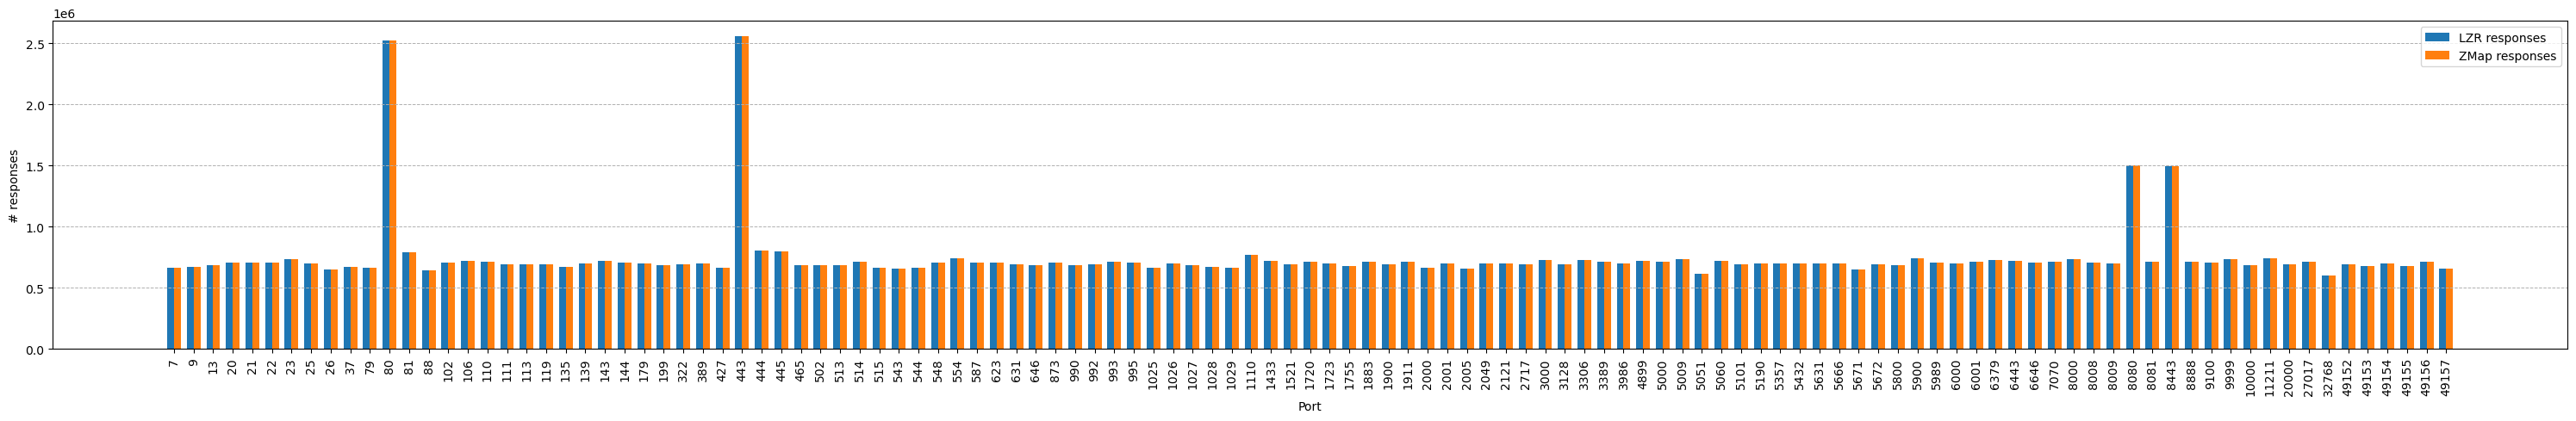

In [218]:
# in this plot, the bars should match when using the real data...

lzr_total_pdf = lzr_gp_pdf.groupby("port")["count"].sum().reset_index()

plot_totals_df = lzr_total_pdf.rename(columns={"count": "count_lzr"}
).merge(
    zmap_gp_pdf.rename(columns={"count": "count_zmap"}),
    on="port",
    how="outer"
).fillna(0).sort_values("port")

x = np.arange(len(plot_totals_df["port"]))  # one position per port
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(30, 5))

ax.bar(x - width/2, plot_totals_df["count_lzr"], width, label="LZR responses")
ax.bar(x + width/2, plot_totals_df["count_zmap"], width, label="ZMap responses")

ax.set_xlabel("Port")
ax.set_ylabel("# responses")
ax.set_xticks(x)
ax.set_xticklabels(plot_totals_df["port"])
plt.xticks(rotation=90)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7)
ax.legend()

plt.tight_layout()
plt.savefig("figures/lzr_zmap_resp.pdf")
plt.show()

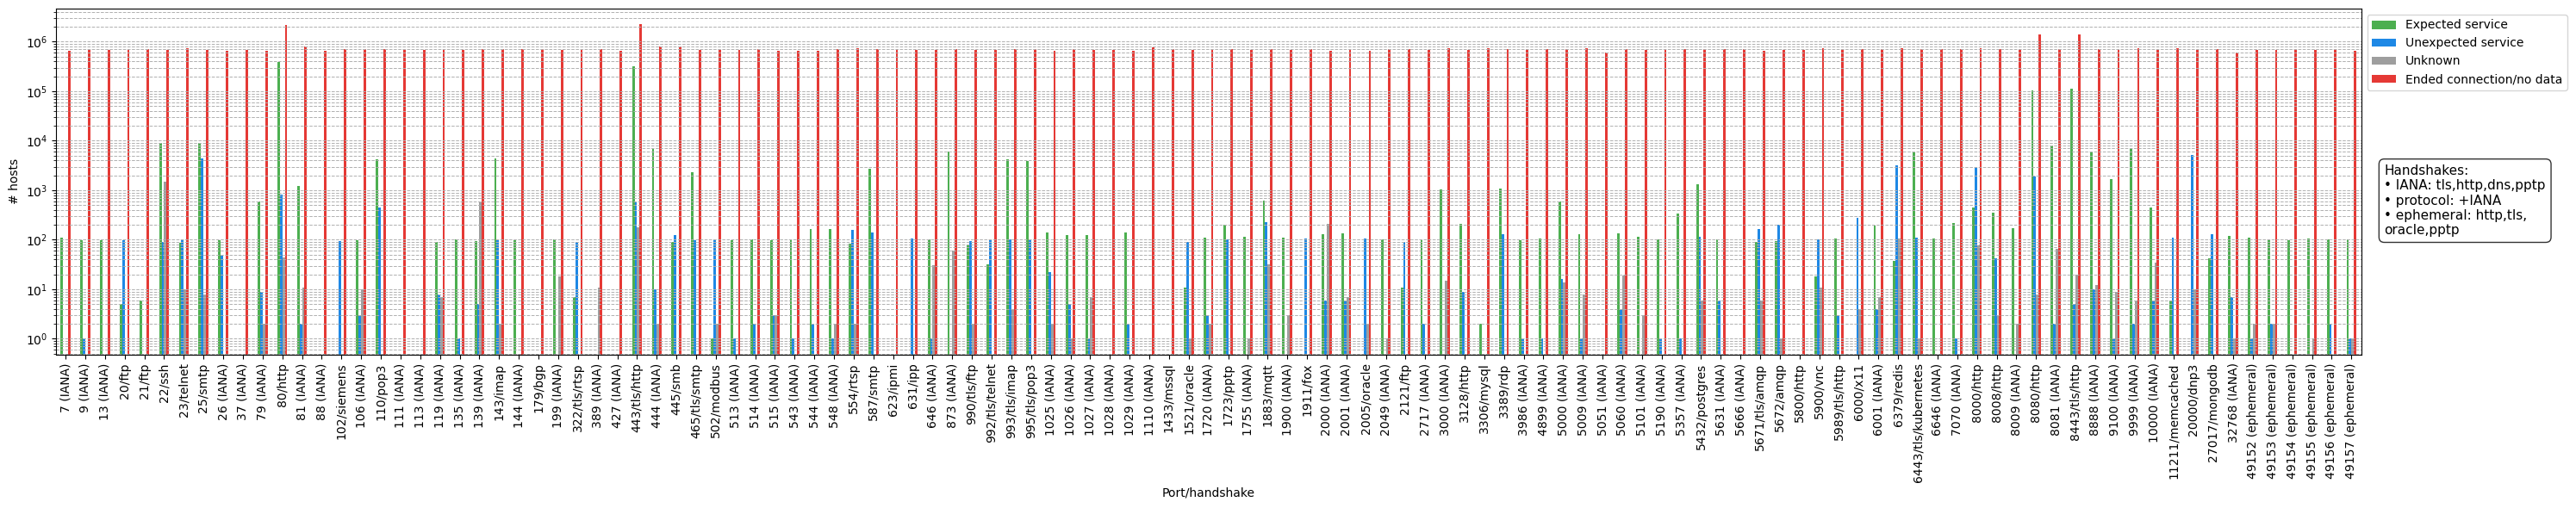

In [102]:
# OLD CODE!
if False:
    _pdf = lzr_gp_pdf[~(lzr_gp_pdf["fingerprint"] == "unknown")].copy()
    
    _lzr_unknown_nodata_pdf = lzr_unknown_nodata_pdf.groupby(["port"])["count"].sum().reset_index().copy()
    _lzr_unknown_nodata_pdf["fingerprint"] = "Ended connection/no data"
    _lzr_unknown_pdf = lzr_unknown_pdf.copy()
    _lzr_unknown_pdf["fingerprint"] = "unknown"
    
    pdf = pd.concat([_pdf, _lzr_unknown_nodata_pdf, _lzr_unknown_pdf])
    pdf["service_stat"] = pdf.apply(lambda row: expected_and_unexpected_service(row["port"], row["fingerprint"], is_udp=False), axis=1)
    
    plot_pdf = pdf.groupby(["port", "service_stat"])["count"].sum().unstack(fill_value=0)
    #plot_pdf = pdf.groupby(["port", "service_stat"])["count"].sum().unstack(fill_value=0).merge(
    #    zmap_gp_pdf.rename(columns={"count": "SYN_ACK"}),
    #    left_index=True,
    #    right_on="port",
    #    how="left"
    #).set_index("port")
    
    color_map = {
        "Expected service": "#4CAF50",          # green
        "Unexpected service": "#1E88E5",        # blue
        "Unknown": "#9E9E9E",                    # gray
        "Ended connection/no data": "#E53935",  # red
    }
    #colors = [color_map[col] for col in plot_pdf.columns]
    colors = color_map.values()
    ax = plot_pdf[['Expected service', 'Unexpected service', 'Unknown', 'Ended connection/no data']].plot(
        kind="bar",
        #stacked=True,
        logy=True,
        color=colors,
        figsize=(30, 6)
    )
    
    text = (
        "Handshakes:\n"
        "• IANA: tls,http,dns,pptp\n"
        "• protocol: +IANA\n"
        "• ephemeral: http,tls,\noracle,pptp"
    )
    
    ax.text(
        1.01, 0.55, text,               # x,y in axes coords
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
    )
    
    labels = [get_labels_on_port(p) for p in plot_pdf.index]
    #ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, ha="center")
    
    ax.set_xlabel("Port/handshake")
    ax.set_ylabel("# hosts")
    #ax.set_title("Service categories per port")
    ax.legend(bbox_to_anchor=(1.0, 1), loc="upper left")
    #ax.set_yscale("log")
    ax.yaxis.grid(True, which="both", linestyle="--", linewidth=0.7)
    ax.xaxis.grid(False)
    plt.tight_layout()
    plt.savefig("figures/lzr_overview.pdf", dpi=600, bbox_inches="tight")
    plt.show()

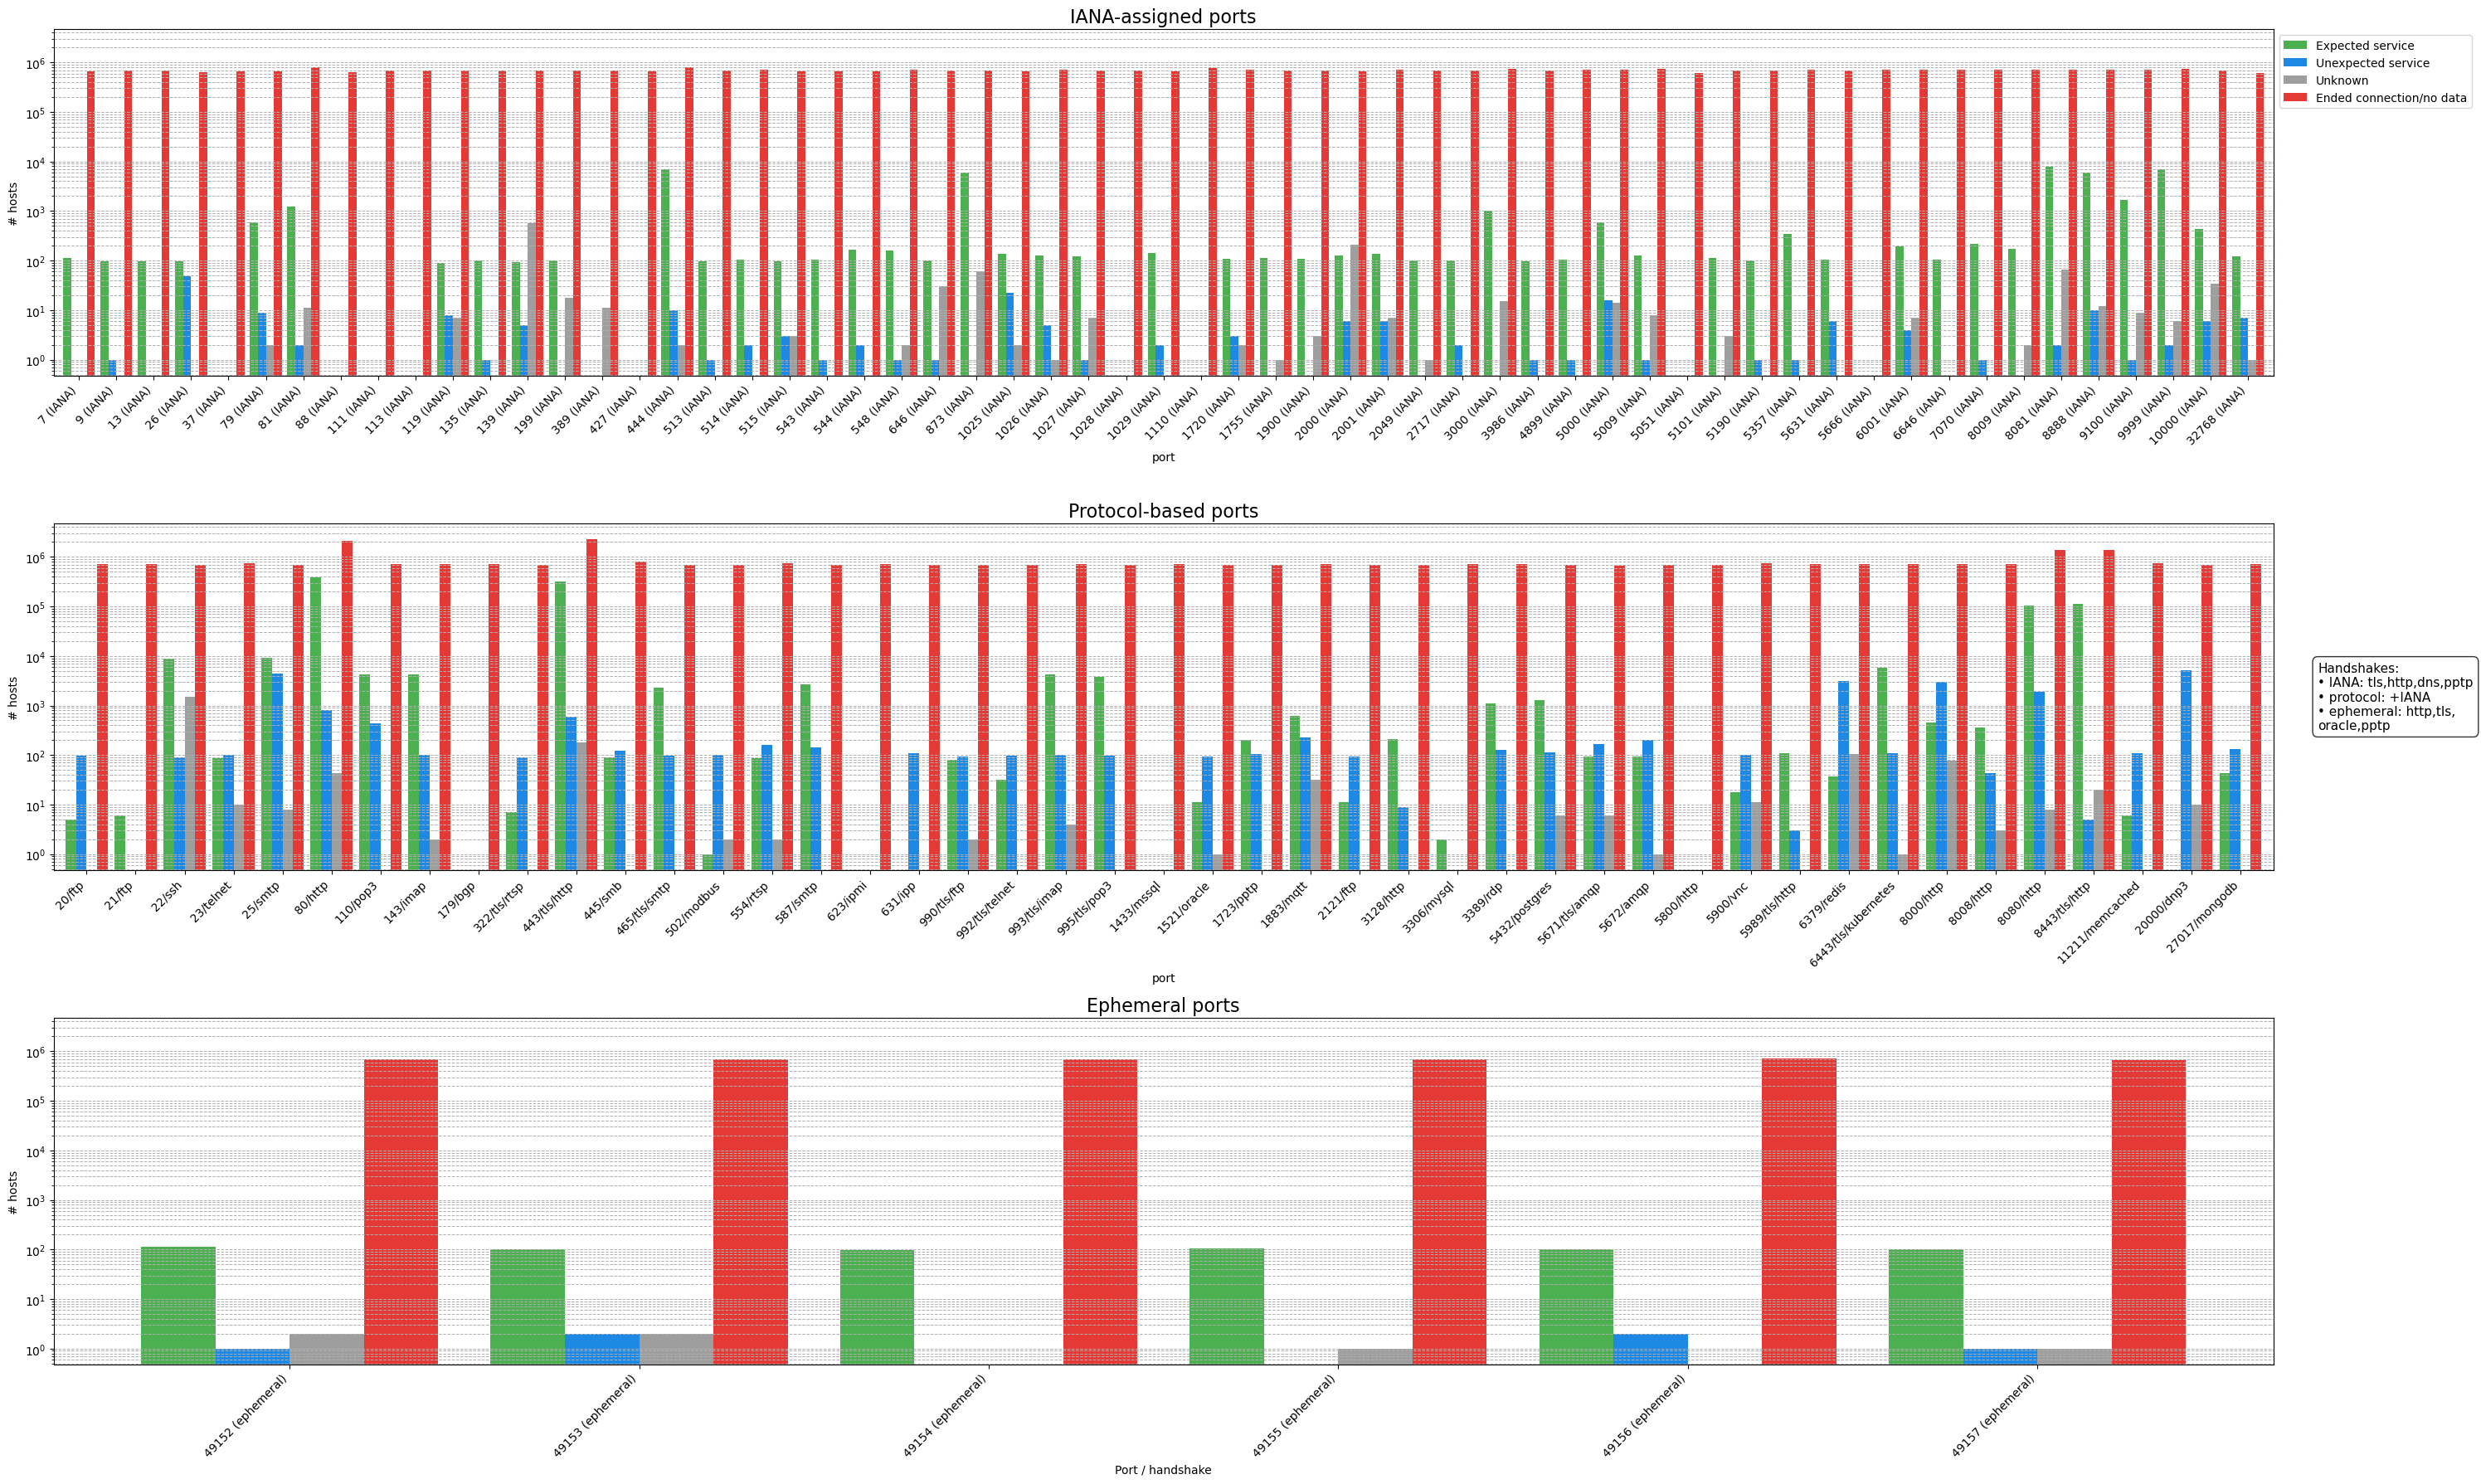

In [103]:
iana_ports = [7,9,13,26,37,79,81,88,111,113,119,135,139,199,389,427,
              444,513,514,515,543,544,548,646,873,1025,1026,1027,1028,1029,
              1110,1720,1755,1900,2000,2001,2049,2717,3000,3986,4899,5000,
              5009,5051,5101,5190,5357,5631,5666,6001,6646,7070,8009,8081,
              8888,9100,9999,10000,32768]

protocol_ports = [20,21,22,23,25,53,80,110,123,143,179,322,443,445,465,502,554,587,
                  623,631,990,992,993,995,1433,1521,1723,1883,2121,3128,3306,
                  3389,5432,5671,5672,5800,5900,5989,6379,6443,8000,8008,
                  8080,8443,11211,20000,27017]

ephemeral_ports = [49152,49153,49154,49155,49156,49157]


plot_pdf = plot_pdf[['Expected service', 'Unexpected service', 'Unknown', 'Ended connection/no data']]

pdf_iana = plot_pdf.loc[plot_pdf.index.isin(iana_ports)]
pdf_protocol = plot_pdf.loc[plot_pdf.index.isin(protocol_ports)]
pdf_ephemeral = plot_pdf.loc[plot_pdf.index.isin(ephemeral_ports)]

fig, axes = plt.subplots(
    3, 1,
    figsize=(30, 18),
    sharey=True
)

dfs = [pdf_iana, pdf_protocol, pdf_ephemeral]
titles = ["IANA-assigned ports", "Protocol-based ports", "Ephemeral ports"]

for ax, df, title in zip(axes, dfs, titles):
    df.plot(
        kind="bar",
        logy=True,
        color=color_map.values(),
        ax=ax,
        width=0.85
    )
    
    ax.set_title(title, fontsize=16)
    ax.set_ylabel("# hosts")
    ax.yaxis.grid(True, which="both", linestyle="--", linewidth=0.7)
    ax.xaxis.grid(False)

    labels = [get_labels_on_port(p) for p in df.index]
    ax.set_xticklabels(labels, rotation=45, ha="right")

# Only keep legend once
axes[0].legend(bbox_to_anchor=(1.0, 1), loc="upper left")
for ax in axes[1:]:
    ax.get_legend().remove()


text = (
    "Handshakes:\n"
    "• IANA: tls,http,dns,pptp\n"
    "• protocol: +IANA\n"
    "• ephemeral: http,tls,\noracle,pptp"
)

axes[1].text(
    1.02, 0.5,
    text,
    transform=axes[1].transAxes,
    fontsize=11,
    verticalalignment="center",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
)

plt.xlabel("Port / handshake")
plt.tight_layout()
plt.savefig("figures/lzr_overview_split.pdf", dpi=600, bbox_inches="tight")
plt.show()


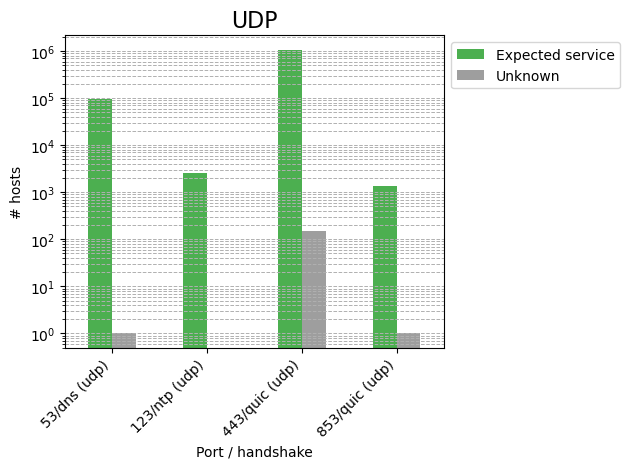

In [126]:
pdf = zmapudp_gp_pdf.copy()

pdf["service_stat"] = pdf.apply(lambda row: expected_and_unexpected_service(row["port"], row["fingerprint"], is_udp=True), axis=1)

plot_pdf = pdf.groupby(["port", "service_stat"])["count"].sum().unstack(fill_value=0)

color_map = {
    "Expected service": "#4CAF50",          # green
    "Unknown": "#9E9E9E",                    # gray
#    "Ended connection/no data": "#E53935",  # red
}
#colors = [color_map[col] for col in plot_pdf.columns]
colors = color_map.values()

ax = plot_pdf.plot(
    #x="port",
    #y="count",
    color=colors,
    kind="bar",
    logy=True,
)

ax.set_title("UDP", fontsize=16)
ax.set_ylabel("# hosts")
ax.yaxis.grid(True, which="both", linestyle="--", linewidth=0.7)
ax.xaxis.grid(False)

labels = [get_labels_on_port(p, is_udp=True) for p in plot_pdf.index]
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend(bbox_to_anchor=(1.0, 1), loc="upper left", title="")


plt.xlabel("Port / handshake")
plt.tight_layout()
plt.savefig("figures/lzr_overview_udp.pdf", dpi=600, bbox_inches="tight")
plt.show()

What are the unknowns?

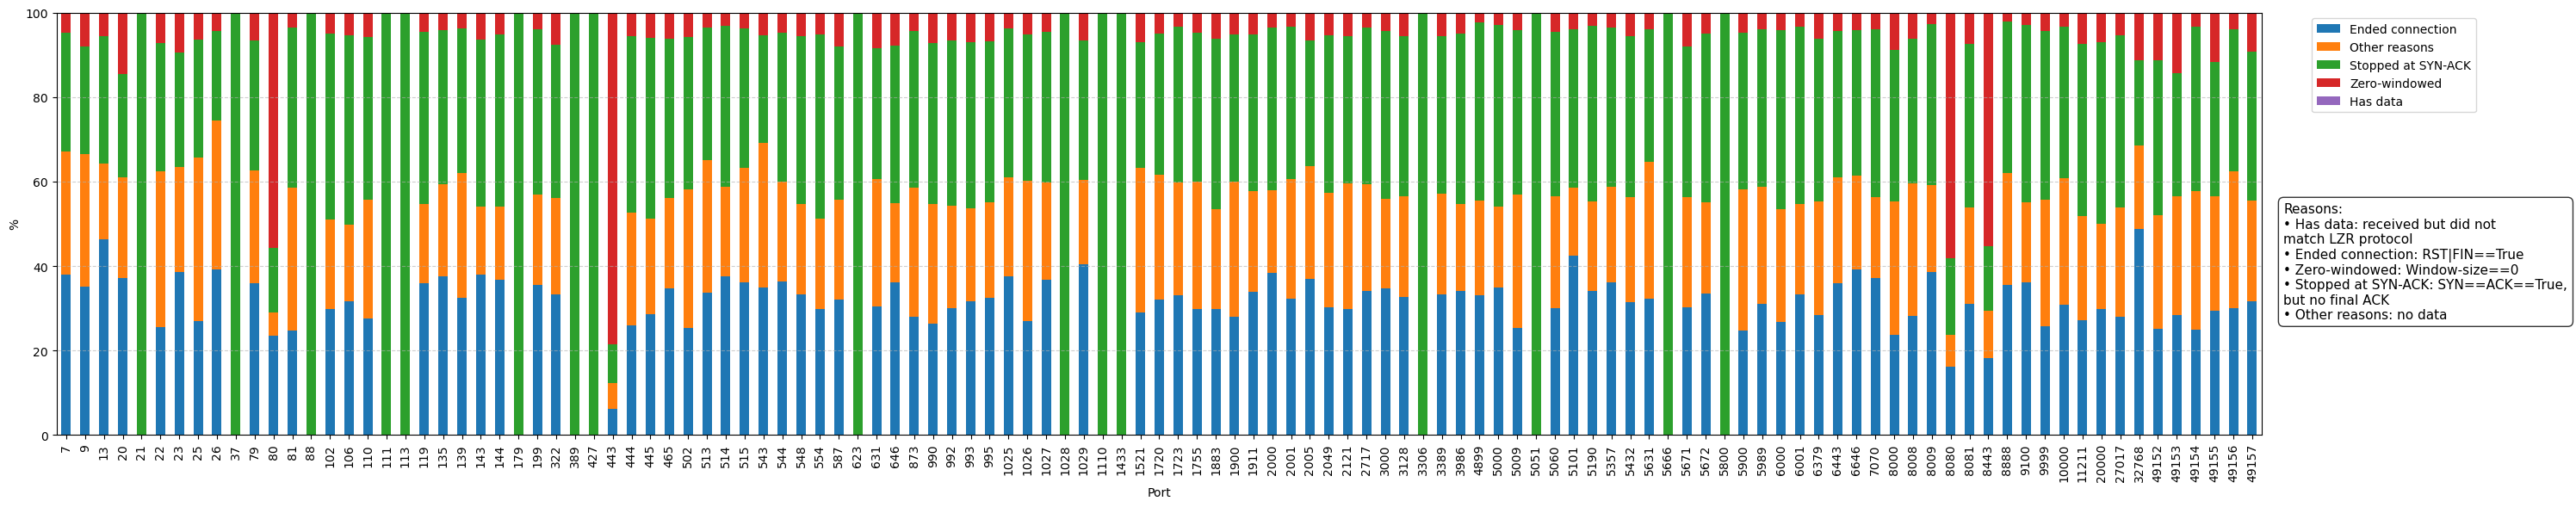

In [63]:
#df_errors_agg = lzr_unknown_nodata_pdf.groupby("port", as_index=False)["count"].sum().copy()
#df_errors_agg.rename(columns={"count": "errors"}, inplace=True)
errors_pivot = lzr_unknown_nodata_pdf.copy().pivot_table(index="port", columns="tcp_reason", values="count", aggfunc="sum").fillna(0)

df_data = lzr_unknown_pdf.copy().rename(columns={"count": "Has data"}).set_index("port")

df = errors_pivot.join(df_data, how="outer").fillna(0)

df["total"] = df.sum(axis=1)

pct_df = df.div(df["total"], axis=0) * 100
pct_df = pct_df.drop(columns="total")
pct_df = pct_df.sort_index()


ax = pct_df.plot(
    kind="bar",
    stacked=True,
    figsize=(30, 6)
)


text = (
    "Reasons:\n"
    "• Has data: received but did not\nmatch LZR protocol\n"
    "• Ended connection: RST|FIN==True\n"
    "• Zero-windowed: Window-size==0\n"
    "• Stopped at SYN-ACK: SYN==ACK==True,\nbut no final ACK\n"
    "• Other reasons: no data"
)

ax.text(
    1.01, 0.55, text,               # x,y in axes coords
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
)


ax.set_ylabel("%")
ax.set_xlabel("Port")
#ax.set_title("Scan Outcomes per Port")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/lzr_unknown_overview.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [11]:
def plot_services(plot_pdf, filename, figsize):
    color_map = {
        "Expected service": "#4CAF50",          # green
        "Unexpected service": "#1E88E5",        # blue
        "Unknown": "#9E9E9E",                    # gray
        "Ended connection/no data": "#E53935",  # red
    }
    #colors = [color_map[col] for col in plot_pdf.columns]
    colors = color_map.values()
    ax = plot_pdf[['Expected service', 'Unexpected service', 'Unknown', 'Ended connection/no data']].plot(
        kind="bar",
        #stacked=True,
        color=colors,
        figsize=figsize,
        logy=True
    )
    
    text = (
        "Handshakes:\n"
        "• IANA: tls,http,dns,pptp\n"
        "• ephemeral: http,tls,\noracle,pptp"
    )
    
    ax.text(
        1.02, 0.55, text,               # x,y in axes coords
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
    )
    
    
    
    labels = [get_labels_on_port(p) for p in plot_pdf.index]
    #ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, ha="center")
    
    ax.set_xlabel("Port/handshake")
    ax.set_ylabel("# hosts")
    #ax.set_title("Service categories per port")
    ax.legend(bbox_to_anchor=(1.0, 1), loc="upper left")
    #ax.set_yscale("log")
    ax.yaxis.grid(True, which="both", linestyle="--", linewidth=0.7)
    ax.xaxis.grid(False)
    plt.tight_layout()
    plt.savefig(filename, dpi=600, bbox_inches="tight")
    plt.show()

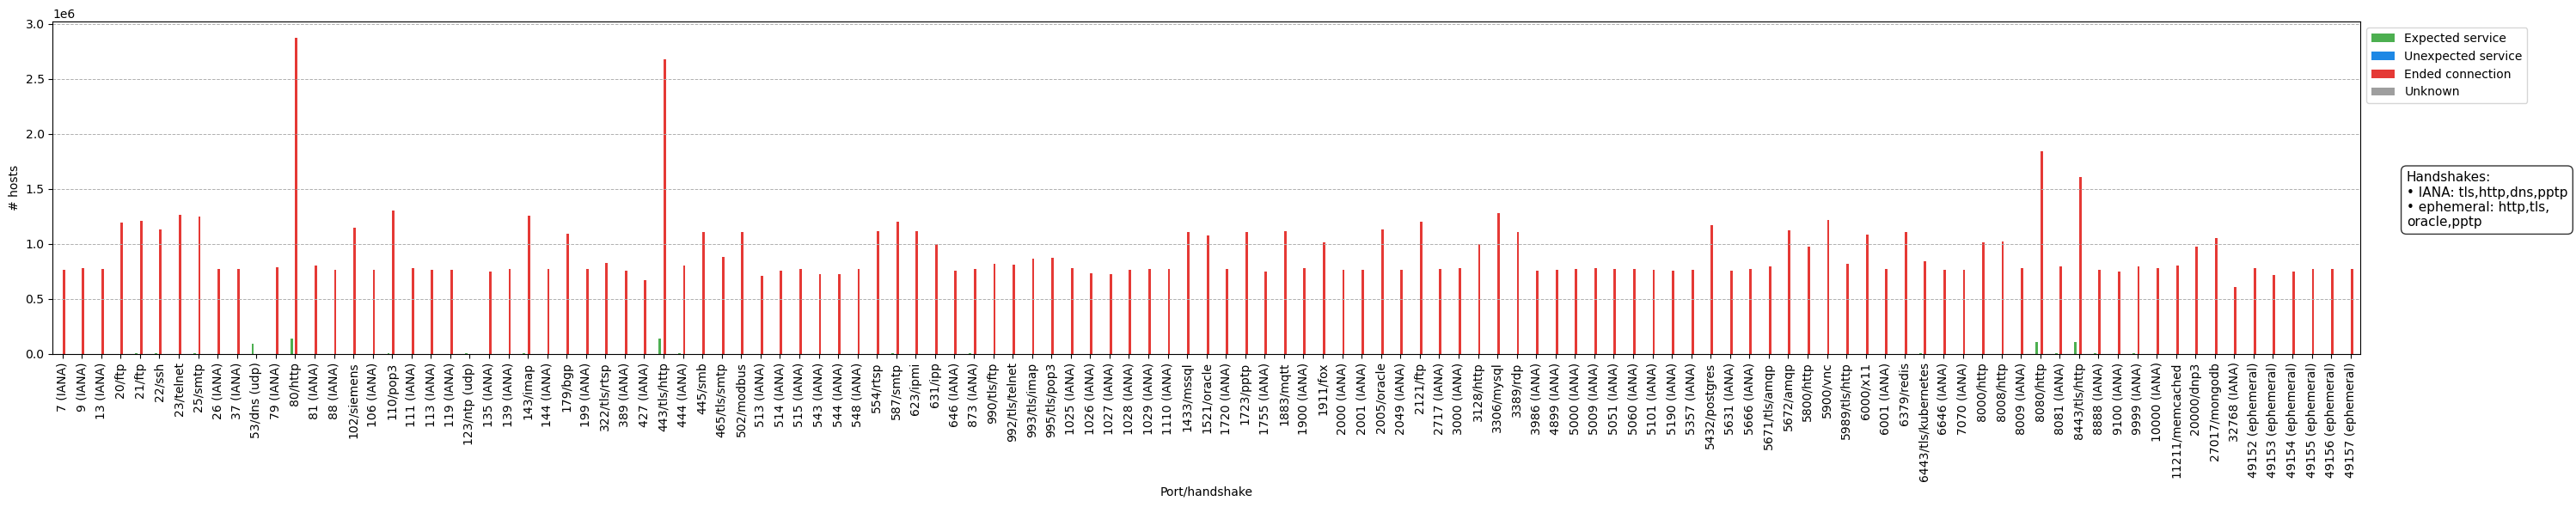

In [108]:
# IGNORE THIS
if False:
    pdf = pd.concat([lzr_gp_pdf, zmapudp_gp_pdf], ignore_index=True).copy()
    
    pdf["service_stat"] = pdf.apply(lambda row: expected_and_unexpected_service(row["port"], row["fingerprint"]), axis=1)
    _plot_pdf = pdf.groupby(["port", "service_stat"])["count"].sum().unstack(fill_value=0).merge(
        zmap_gp_pdf.rename(columns={"count": "SYN_ACK"}),
        left_index=True,
        right_on="port",
        how="left"
    ).set_index("port")
    
    nodata_pdf = lzr_unknown_nodata_pdf.groupby("port", as_index=False)["count"].sum().rename(columns={"count": "Ended connection"})
    lzr_unknown_pdf.rename(columns={"count": "Unknown"}, inplace=True)
    
    plot_pdf = _plot_pdf.drop(columns=["Unknown"]
    ).merge(
        nodata_pdf, left_index=True, right_on="port", how="left").set_index("port"
    ).merge(lzr_unknown_pdf, left_index=True, right_on="port", how="left"
    ).fillna({"Ended connection": 0, "Unknown": 0}).set_index("port")
    
    plot_pdf["Ended connection"] = (
        plot_pdf["Ended connection"].fillna(0)
        + plot_pdf["SYN_ACK"].fillna(0)
    )
    
    plot_pdf = plot_pdf.drop(columns=["SYN_ACK"])
    
    plot_services(plot_pdf, "figures/lzr_overview.pdf", figsize=(30, 6))

Small sample

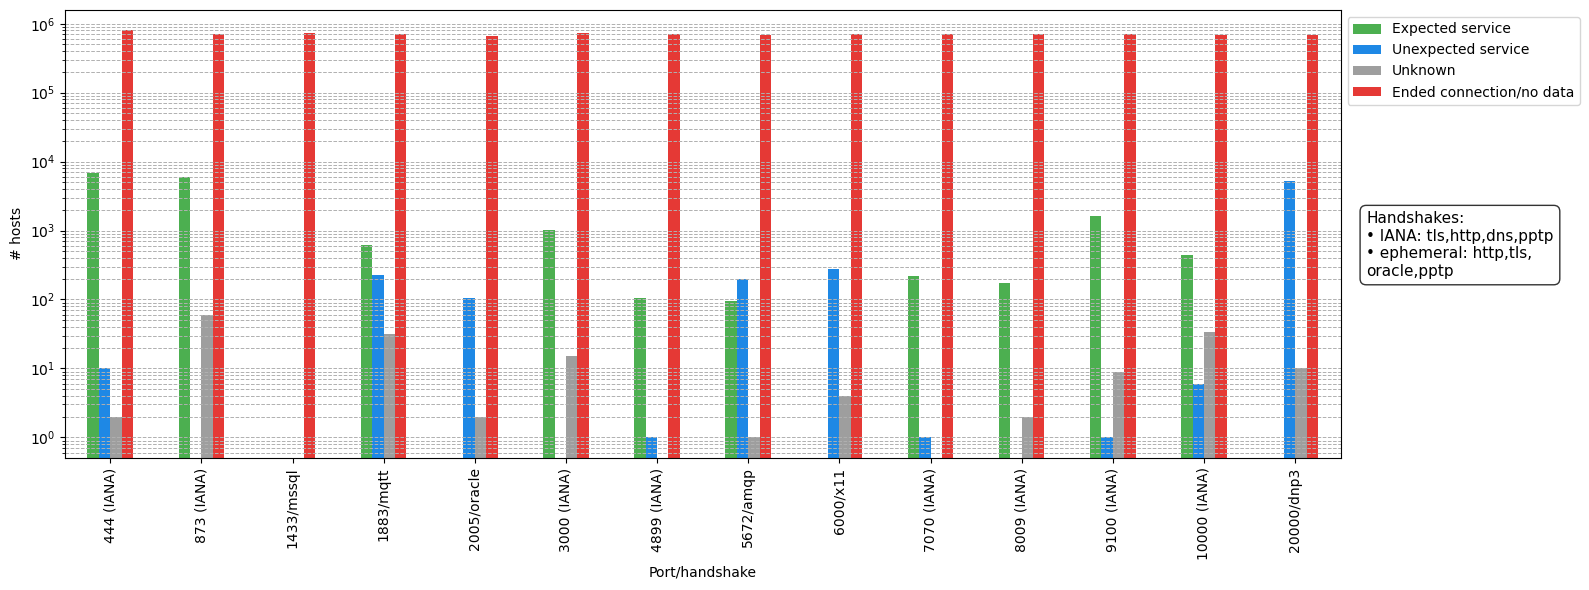

In [75]:
# 88 kerberos
# 444 network paging protocol
# 873 rsync
# 1433 mssql
# 1883 mqtt
# 2005 oracle
# 3000 hp-telnet
# 4899 remote desktop (radmin)
# 3389 rdp
# 5672 amqp
# 6000 X11
# 7070 arcp (realtime audio/video)
#  https://docs.redhat.com/en/documentation/red_hat_enterprise_linux/9/html/managing_storage_devices/configuring-nvme-over-fabrics-using-nvme-tcp_managing-storage-devices
# 8009 storage device (see above)
# 9100 direct printing over tcp
# 10000 data management
# 20000 dnp3

allowlist_ports = [444, 873, 1433, 1883, 2005, 3000, 4899, 5672, 6000, 7070, 8009, 9100, 10000, 20000]

plot_services(plot_pdf[plot_pdf.index.isin(allowlist_ports)], "figures/lzr_overview_simplified.pdf", figsize=(16,6))

IP level discovery

In [221]:
print("total hosts")
total_hosts_ip_cnt = lzr_df.select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day").unionByName(
    zmapudp_df.withColumn(
        "fingerprint", fp_zmap(psf.col("port"), psf.col("data"), psf.col("saddr"))
    ).select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day")
).select("ip").distinct().count()

total hosts


2732946

In [222]:
print("# of hosts without any service attached")
without_service_ips_cnt = lzr_df.select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day").unionByName(
    zmapudp_df.withColumn(
        "fingerprint", fp_zmap(psf.col("port"), psf.col("data"), psf.col("saddr"))
    ).select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day")
).groupBy("ip").agg(
    psf.collect_set("port").alias("ports"),
    psf.collect_set("fingerprint").alias("fingerprints")
).filter(
    (psf.size("fingerprints") == 1)
    & (psf.col("fingerprints")[0] == "unknown")
).count()

# of hosts without any service attached


1198651

In [226]:
1198651/2732946*100

print(total_hosts_ip_cnt, without_service_ips_cnt, without_service_ips_cnt/total_hosts_ip_cnt * 100)

43.85930054966325

In [227]:
print("# of hosts with a service attached")
lzr_df.select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day").unionByName(
    zmapudp_df.withColumn(
        "fingerprint", fp_zmap(psf.col("port"), psf.col("data"), psf.col("saddr"))
    ).select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day")
).filter(
    psf.col("fingerprint") != "unknown"
).select("ip").distinct().count()

# of hosts with a service attached


1534295

In [230]:
print("% of unknowns:", (2732946-1534295)/2732946*100)
print("% of knowns:", 1534295/2732946*100)

% of unknowns: 43.85930054966325
% of knowns: 56.14069945033674


Prefix level discovery

In [232]:
print("# prefixes")
total_hosts_prefix_cnt = lzr_df.select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day").unionByName(
    zmapudp_df.withColumn(
        "fingerprint", fp_zmap(psf.col("port"), psf.col("data"), psf.col("saddr"))
    ).select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day")
).withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).select("prefix").distinct().count()

# prefixes


13775

In [231]:
print("# prefixes with a service")
with_service_hosts_prefix_cnt = lzr_df.select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day").unionByName(
    zmapudp_df.withColumn(
        "fingerprint", fp_zmap(psf.col("port"), psf.col("data"), psf.col("saddr"))
    ).select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day")
).withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).filter(
    psf.col("fingerprint") != "unknown"
).select("prefix").distinct().count()

# prefixes with a service


13189

In [234]:
print("% of prefixes with only unknowns", (total_hosts_prefix_cnt-with_service_hosts_prefix_cnt)/total_hosts_prefix_cnt*100)
print("% of prefixes with at least one known service", with_service_hosts_prefix_cnt/total_hosts_prefix_cnt*100)

% of prefixes with only unknowns 4.254083484573503
% of prefixes with at least one known service 95.7459165154265


In [128]:
zmapudp_df.withColumn(
    "fingerprint", fp_zmap(psf.col("port"), psf.col("data"), psf.col("saddr"))
).select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day").groupBy("fingerprint").count().show()

+-----------+-------+
|fingerprint|  count|
+-----------+-------+
|    unknown|    151|
|    quic-h3|1079541|
|        dns|  95167|
|   quic-doq|   1339|
|        ntp|   2547|
+-----------+-------+



In [11]:
# TODO reproduce table 3

## top used ports per prefix

In [87]:
port_cnt_pdf = lzr_df.select(psf.col("saddr").alias("ip"), "port", "fingerprint").unionByName(
    zmapudp_df.withColumn(
        "fingerprint", fp_zmap(psf.col("port"), psf.col("data"), psf.col("saddr"))
    ).select(psf.col("saddr").alias("ip"), "port", "fingerprint")
).filter(
    psf.col("fingerprint") != "unknown"
).withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).select("prefix", "port").distinct().groupBy("port").count().toPandas()

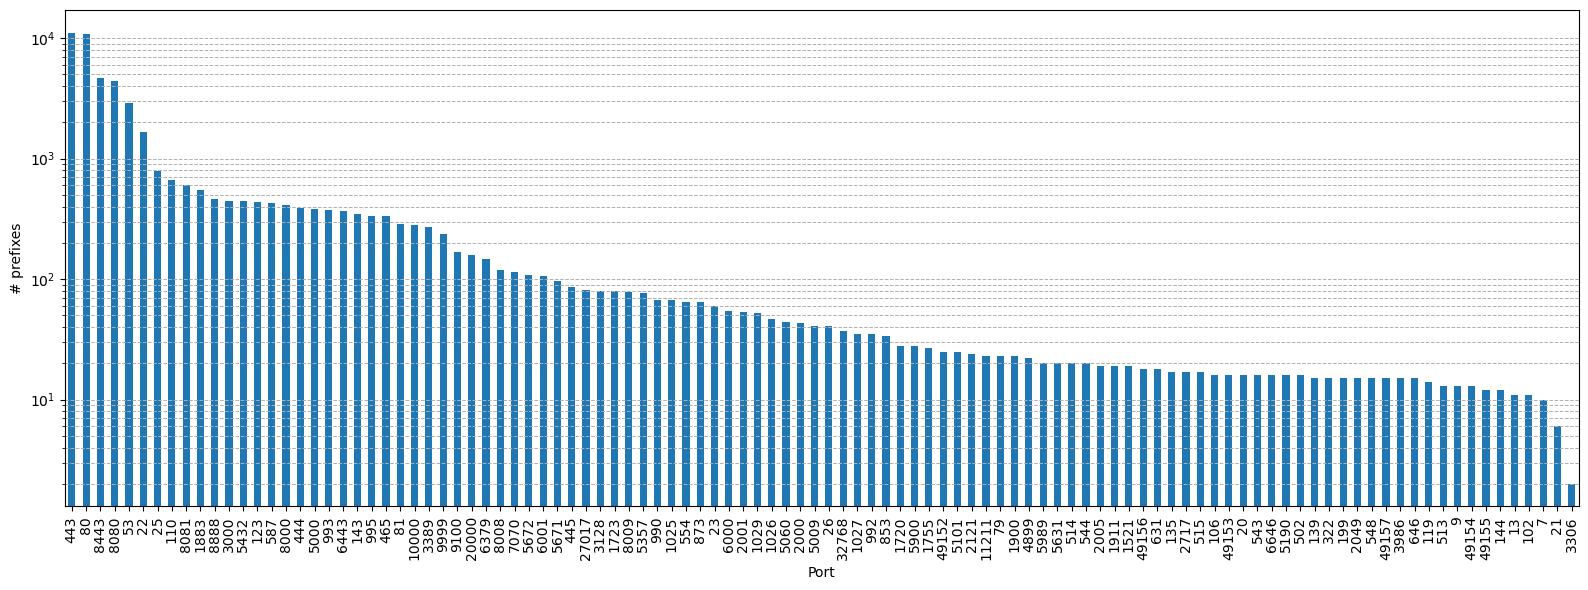

In [94]:
ax = port_cnt_pdf.sort_values(by="count", ascending=False).plot(
    x="port",
    y="count",
    kind="bar",
    figsize=(16,6),
    logy=True,
    legend=""
)

ax.set_ylabel("# prefixes")
ax.set_xlabel("Port")
ax.yaxis.grid(True, which="both", linestyle="--", linewidth=0.7)
ax.xaxis.grid(False)

#labels = [get_labels_on_port(p) for p in port_cnt_pdf.sort_values(by="count", ascending=False)["port"].to_list()]
#ax.set_xticklabels(labels, ha="center")

plt.tight_layout()
plt.show()

## Which data do we have with TLS?

In [96]:
lzr_df.filter(
    psf.col("fingerprint") == "tls"
).select("data").show(1, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|data                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [97]:
lzr_df.select("data").printSchema()

root
 |-- data: string (nullable = true)



Hence, we must look at Censys data... or save pcaps (a lot of efforts)

## Export to/import from IP2Location

In [16]:
# export for ip2location
lzr_df.select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day").unionByName(
    zmapudp_df.withColumn(
        "fingerprint", fp_zmap(psf.col("port"), psf.col("data"), psf.col("saddr"))
    ).select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day")
#).groupBy("ip", "year", "month", "day").agg(
#    psf.collect_set("port").alias("ports"),
#    psf.collect_set("fingerprint").alias("fingerprints")
).select("ip", "year", "month", "day" #, "port", "fingerprint", 
#).coalesce(1).write.partitionBy("year", "month", "day").parquet("s3a://luvizottocesarg-tmp/anycast-service-discovery/lzr/ip2location/input/")
).distinct().coalesce(1).write.partitionBy("year", "month", "day").csv("s3a://luvizottocesarg-tmp/anycast-service-discovery/lzr/ip2location/input/vp=nl-ens", header=True)

In [42]:
# import from ip2location
inputip2loc_df = lzr_df.select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day").unionByName(
    zmapudp_df.withColumn(
        "fingerprint", fp_zmap(psf.col("port"), psf.col("data"), psf.col("saddr"))
    ).select(psf.col("saddr").alias("ip"), "port", "fingerprint", "year", "month", "day")
).groupBy("ip", "year", "month", "day").agg(
    psf.collect_set("port").alias("ports"),
    psf.collect_set("fingerprint").alias("fingerprints")
)

try:
    ip2loc_lzr_df.unpersist()
except:
    pass

ip2loc_lzr_df = spark.read.csv(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/lzr/ip2location/output/vp=nl-ens/year={zmaptcp_ts.year}/month={zmaptcp_ts.month:02d}/day={zmaptcp_ts.day:02d}", header=True
).join(
    inputip2loc_df,
    on=["ip"],
    how="inner"
).withColumn(
    "isp", psf.when(psf.lower(psf.col("isp")).contains("amazon"), "Amazon.com Inc.").otherwise(psf.col("isp"))  # IPInfo and bgp.he finds Amazon Technologies is the same as Amazon.com Inc. so I'm grouping to make it easy...
).withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
)
ip2loc_lzr_df.printSchema()
ip2loc_lzr_df.persist()

root
 |-- ip: string (nullable = true)
 |-- ip_decimal: string (nullable = true)
 |-- cc: string (nullable = true)
 |-- c_name: string (nullable = true)
 |-- isp: string (nullable = true)
 |-- usage_type: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- ports: array (nullable = false)
 |    |-- element: integer (containsNull = false)
 |-- fingerprints: array (nullable = false)
 |    |-- element: string (containsNull = false)
 |-- prefix: string (nullable = true)



DataFrame[ip: string, ip_decimal: string, cc: string, c_name: string, isp: string, usage_type: string, year: int, month: int, day: int, ports: array<int>, fingerprints: array<string>, prefix: string]

In [21]:
ip2loc_lzr_df.show()

+---------------+----------+---+--------------------+--------------------+----------+----+-----+---+--------------------+--------------------+
|             ip|ip_decimal| cc|              c_name|                 isp|usage_type|year|month|day|               ports|        fingerprints|
+---------------+----------+---+--------------------+--------------------+----------+----+-----+---+--------------------+--------------------+
|      1.0.0.132|  16777348| AU|           Australia|APNIC and CloudFl...|       CDN|2026|    2|  4|[8443, 443, 80, 8...|  [unknown, quic-h3]|
|      1.1.1.109|  16843117| AU|           Australia|APNIC and CloudFl...|       CDN|2026|    2|  4|[8443, 443, 80, 8...|  [unknown, quic-h3]|
|      1.1.1.125|  16843133| AU|           Australia|APNIC and CloudFl...|       CDN|2026|    2|  4|[8443, 443, 80, 8...|  [unknown, quic-h3]|
|      1.1.1.250|  16843258| AU|           Australia|APNIC and CloudFl...|       CDN|2026|    2|  4|[8443, 443, 80, 8...|  [unknown, quic-h3]|

In [39]:
# multiple ports may provide the same service... that's why size(ports) != size(fingerprints)
ip2loc_lzr_df.withColumns({
    "ports_size": psf.size(psf.col("ports")),
    "fps_size": psf.size(psf.col("fingerprints"))
}).withColumn(
    "equal_sizes", psf.col("ports_size") == psf.col("fps_size")
).groupBy("equal_sizes").count().show()

+-----------+------+
|equal_sizes| count|
+-----------+------+
|       true|687689|
|      false|556737|
+-----------+------+



## Service/operator analysis

### Understanding ASes where services are provided

what are the top ASes (prefix-count to avoid HRP overestimation)? 

In [43]:
ip2loc_lzr_df.dropDuplicates(subset=["prefix"]
).groupBy("isp").count().sort("count", ascending=False).show()

+--------------------+-----+
|                 isp|count|
+--------------------+-----+
|          Google LLC| 4231|
|     CloudFlare Inc.| 2699|
|     Amazon.com Inc.| 1289|
|         Fastly Inc.|  816|
|        Afilias Inc.|  309|
|         Fly.io Inc.|  194|
|  Nazwa.pl Sp.z.o.o.|  193|
|Akamai Technologi...|  115|
|Microsoft Corpora...|  107|
|      NetActuate Inc|  102|
|         Vercara LLC|   98|
|     GoDaddy.com LLC|   97|
|   Aceville Pte.Ltd.|   75|
|       Woodynet Inc.|   72|
|             OVH SAS|   70|
|Windstream Commun...|   52|
|Palo Alto Network...|   51|
|Tencent Cloud Com...|   42|
| SK Broadband Co Ltd|   40|
|        Radware Inc.|   40|
+--------------------+-----+
only showing top 20 rows



In [179]:
service_cloudflare_pdf = ip2loc_lzr_df.filter(psf.lower(psf.col("isp")).contains("cloudflare")
).select(psf.explode_outer(psf.col("fingerprints")).alias("fingerprint"), "isp"
).groupBy("isp", "fingerprint").count().toPandas()

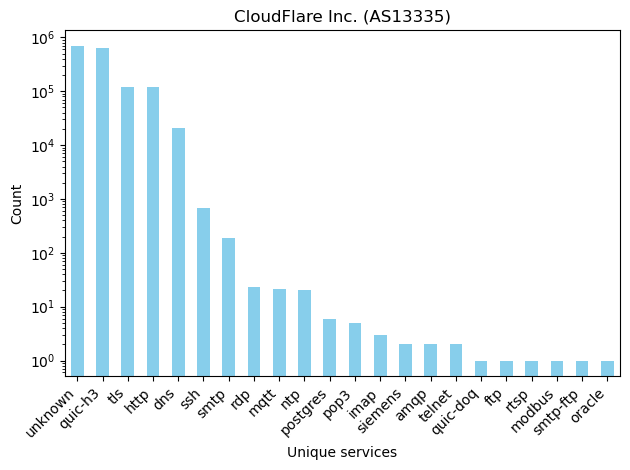

In [180]:
fig, ax = plt.subplots()

service_cloudflare_pdf[service_cloudflare_pdf["isp"] == "CloudFlare Inc."].sort_values(by="count", ascending=False).plot(
    kind="bar",
    x="fingerprint",
    y="count",
    color="skyblue",
    ax=ax
)

ax.set_xlabel("Unique services")
ax.set_ylabel("Count")
ax.set_yscale("log")
ax.set_title("CloudFlare Inc. (AS13335)")
ax.get_legend().remove()
ax.tick_params(axis="x", rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), ha="right")

fig.tight_layout()
plt.show()

In [181]:
service_google_pdf = ip2loc_lzr_df.filter(psf.lower(psf.col("isp")).contains("google")
).select(psf.explode_outer(psf.col("fingerprints")).alias("fingerprint"), "isp"
).groupBy("isp", "fingerprint").count().toPandas()

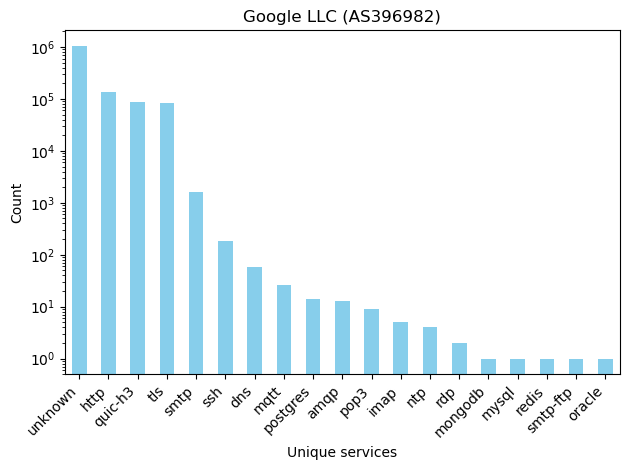

In [182]:
fig, ax = plt.subplots()

service_google_pdf[service_google_pdf["isp"] == "Google LLC"].sort_values(by="count", ascending=False).plot(
    kind="bar",
    x="fingerprint",
    y="count",
    color="skyblue",
    ax=ax
)

ax.set_xlabel("Unique services")
ax.set_ylabel("Count")
ax.set_yscale("log")
ax.set_title("Google LLC (AS396982)")
ax.get_legend().remove()
ax.tick_params(axis="x", rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), ha="right")

fig.tight_layout()
plt.show()

How services are distributed among top 5 ASes (ranked by nr of services they provide by prefix)? -- excludes unknown

In [47]:
prefix_fp_isp_df = ip2loc_lzr_df.select("prefix", psf.explode_outer("fingerprints").alias("fingerprint"), "isp"
).filter(
    psf.col("fingerprint") != "unknown"
).distinct()

head5rows = prefix_fp_isp_df.groupBy("isp").count().sort("count", ascending=False
).head(5)

top5_isps = [row.isp for row in head5rows]
print(top5_isps)

['Google LLC', 'CloudFlare Inc.', 'Amazon.com Inc.', 'Fastly Inc.', 'Fly.io Inc.']


In [75]:
head10rows = ip2loc_lzr_df.select("prefix", psf.explode_outer("fingerprints").alias("fingerprint"), "isp"
).filter(
    psf.col("fingerprint") != "unknown"
).distinct(
).groupBy("fingerprint").count().sort("count", ascending=False).head(6)

top10_fingerprints = [r["fingerprint"] for r in head10rows]


isp_fp_pdf = ip2loc_lzr_df.select("prefix", psf.explode_outer("fingerprints").alias("fingerprint"), "isp"
).filter(
    psf.col("fingerprint") != "unknown"
).filter(
    psf.col("isp").isin(top5_isps)
).filter(
    psf.col("fingerprint").isin(top10_fingerprints)
).distinct(
).groupBy("fingerprint", "isp").count().toPandas()
        
plot_pdf = isp_fp_pdf.pivot(index="fingerprint", columns="isp", values="count").fillna(0)
plot_pdf_pct = plot_pdf.div(plot_pdf.sum(axis=1), axis=0) * 100

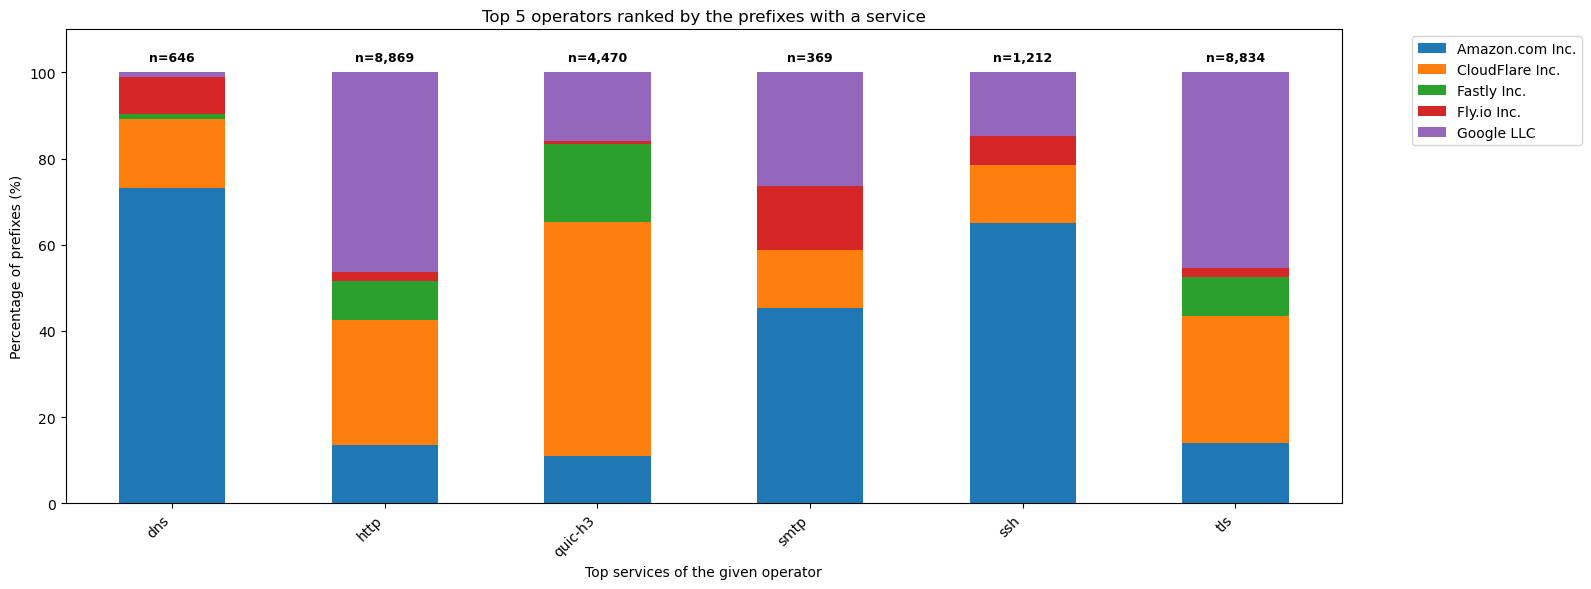

In [131]:
ax = plot_pdf_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(16,6)
)

# Number of ISPs (bars per group)
n_isps = len(plot_pdf_pct.columns)

service_totals = plot_pdf.sum(axis=1)
for i, total in enumerate(service_totals):
    # x position: center of the bar group
    x_pos = i

    ax.text(
        x_pos,
        102,  # slightly above 100%
        f"n={int(total):,}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_ylim(0, 110)  # leave room for labels
# the operators may host many other services, but they are less relevant...
ax.set_title("Top 5 operators ranked by the prefixes with a service")
ax.set_xlabel("Top services of the given operator")
ax.set_ylabel("Percentage of prefixes (%)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

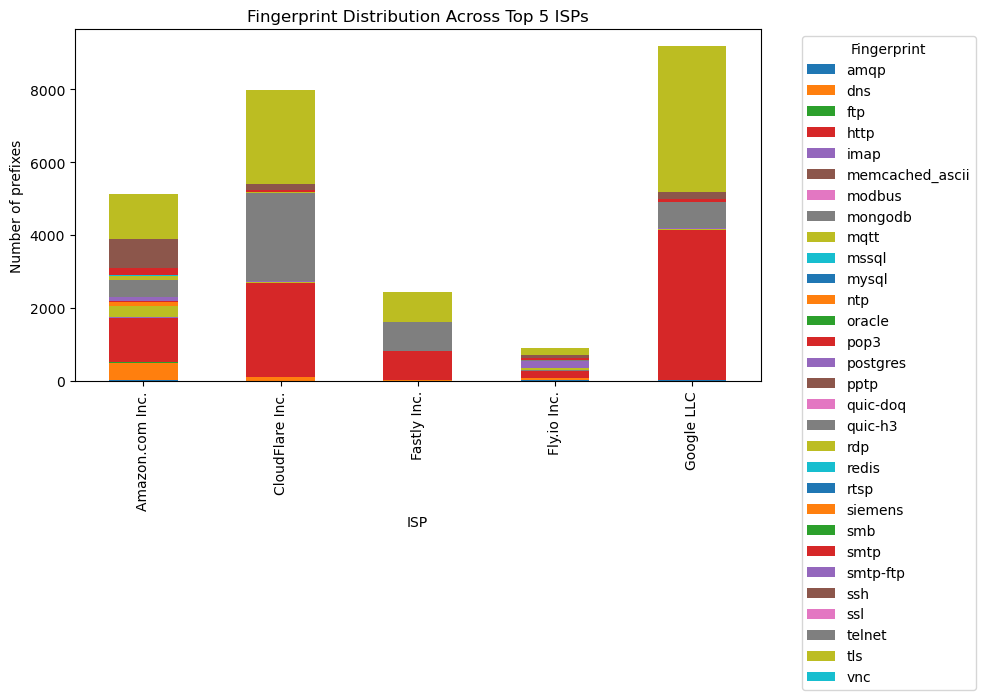

In [53]:
# view of isp on x axis, fingerprint on y axis
isp_fp_pdf = prefix_fp_isp_df.filter(
    psf.col("isp").isin(top5_isps)
).groupBy("isp", "fingerprint").count().toPandas()

plot_pdf = isp_fp_pdf.pivot(index="isp", columns="fingerprint", values="count").fillna(0)

ax = plot_pdf.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

ax.set_ylabel("Number of prefixes")
ax.set_xlabel("ISP")
ax.set_title("Fingerprint Distribution Across Top 5 ISPs")
ax.legend(title="Fingerprint", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Single purpose prefixes

how many unique services run on a prefix?

In [183]:
ip2loc_lzr_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).select("prefix", "isp", psf.explode_outer(psf.col("fingerprints")).alias("fingerprint")
).groupBy("prefix", "isp").agg(
    psf.collect_set(psf.col("fingerprint")).alias("fingerprints")
).withColumn(
    "nr_services", psf.size(psf.col("fingerprints"))
).groupBy("prefix", "isp", "nr_services").count().sort("nr_services", ascending=False).show(truncate=False)

+----------------+----------------+-----------+-----+
|prefix          |isp             |nr_services|count|
+----------------+----------------+-----------+-----+
|178.32.120.0/24 |OVH SAS         |18         |1    |
|185.172.175.0/24|MB Teorita      |17         |1    |
|192.95.20.0/24  |OVH Hosting Inc.|17         |1    |
|83.147.29.0/24  |Digital Value SL|17         |1    |
|91.121.47.0/24  |OVH SAS         |17         |1    |
|141.98.157.0/24 |UAB Linama      |16         |1    |
|91.121.45.0/24  |OVH SAS         |15         |1    |
|46.105.48.0/24  |OVH SAS         |15         |1    |
|46.105.50.0/24  |OVH SAS         |15         |1    |
|54.39.46.0/24   |OVH Hosting Inc.|15         |1    |
|145.239.37.0/24 |OVH SAS         |14         |1    |
|46.105.41.0/24  |OVH SAS         |14         |1    |
|192.95.19.0/24  |OVH Hosting Inc.|14         |1    |
|15.204.130.0/24 |OVH US LLC      |14         |1    |
|54.38.226.0/24  |OVH SAS         |14         |1    |
|54.38.110.0/24  |OVH SAS   

In [184]:
ip2loc_lzr_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).filter(
    psf.col("prefix") == "103.177.50.0/24"  # Google LLC
).groupBy("fingerprints").count().show(truncate=False)

+------------+-----+
|fingerprints|count|
+------------+-----+
|[unknown]   |48   |
+------------+-----+



In [185]:
# prefixes with single purpose:
ip2loc_lzr_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).withColumn(
    "nr_services", psf.size(psf.col("fingerprints"))
).filter(
    psf.col("nr_services") == 1
).select("prefix", "fingerprints").distinct(
).groupBy("fingerprints").count(
).sort("count", ascending=False).show(truncate=False)

+------------+-----+
|fingerprints|count|
+------------+-----+
|[unknown]   |7364 |
|[dns]       |1705 |
|[tls]       |536  |
|[http]      |500  |
|[ssh]       |184  |
|[ntp]       |123  |
|[smtp]      |95   |
|[rdp]       |67   |
|[quic-h3]   |52   |
|[pptp]      |27   |
|[telnet]    |11   |
|[rtsp]      |10   |
|[pop3]      |5    |
|[vnc]       |4    |
|[mqtt]      |3    |
|[imap]      |3    |
|[postgres]  |2    |
|[amqp]      |2    |
|[ftp]       |1    |
|[smtp-ftp]  |1    |
+------------+-----+
only showing top 20 rows



In [186]:
# prefixes with single purpose:
ip2loc_lzr_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).withColumn(
    "nr_services", psf.size(psf.col("fingerprints"))
).filter(
    psf.col("nr_services") == 1
).select("prefix", "fingerprints", "isp").distinct(
).groupBy("isp").count(
).sort("count", ascending=False).show(truncate=False)

+-----------------------------+-----+
|isp                          |count|
+-----------------------------+-----+
|Google LLC                   |3949 |
|Amazon.com Inc.              |677  |
|Amazon Technologies Inc.     |600  |
|Afilias Inc.                 |309  |
|CloudFlare Inc.              |282  |
|Nazwa.pl Sp.z.o.o.           |245  |
|OVH SAS                      |229  |
|Fly.io Inc.                  |194  |
|Akamai Technologies Inc.     |126  |
|Vercara LLC                  |111  |
|Radware Inc.                 |107  |
|NetActuate Inc               |91   |
|Virtutel Pty Ltd             |83   |
|SK Broadband Co Ltd          |81   |
|Woodynet Inc.                |70   |
|Fastly Inc.                  |67   |
|Windstream Communications LLC|57   |
|HLL LLC                      |52   |
|OVH US LLC                   |52   |
|Palo Alto Networks Inc       |52   |
+-----------------------------+-----+
only showing top 20 rows



In [193]:
# prefixes with single purpose:
ip2loc_lzr_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).withColumn(
    "nr_services", psf.size(psf.col("fingerprints"))
).filter(
    psf.col("nr_services") == 1
).select("prefix", "fingerprints", "isp").distinct(
).groupBy("isp", "fingerprints").count(
).sort("count", ascending=False).show(truncate=False)

+-----------------------------+------------+-----+
|isp                          |fingerprints|count|
+-----------------------------+------------+-----+
|Google LLC                   |[unknown]   |3862 |
|Amazon.com Inc.              |[unknown]   |640  |
|Amazon Technologies Inc.     |[unknown]   |567  |
|Afilias Inc.                 |[dns]       |309  |
|CloudFlare Inc.              |[unknown]   |279  |
|Fly.io Inc.                  |[unknown]   |194  |
|Nazwa.pl Sp.z.o.o.           |[unknown]   |173  |
|NetActuate Inc               |[dns]       |87   |
|Vercara LLC                  |[dns]       |77   |
|Google LLC                   |[tls]       |72   |
|Woodynet Inc.                |[dns]       |68   |
|OVH SAS                      |[unknown]   |67   |
|Akamai Technologies Inc.     |[dns]       |66   |
|Nazwa.pl Sp.z.o.o.           |[smtp]      |52   |
|Palo Alto Networks Inc       |[unknown]   |50   |
|Akamai Technologies Inc.     |[unknown]   |47   |
|Windstream Communications LLC|

In [237]:
# dns on which prefixes?
ip2loc_lzr_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).select("prefix", "fingerprints", "isp").distinct(
).groupBy("isp", "fingerprints").count(
).filter(
    psf.array_contains(psf.col("fingerprints"), "dns")
).sort("count", ascending=False
).show(truncate=False)

+-----------------------------+------------------------------------------------+-----+
|isp                          |fingerprints                                    |count|
+-----------------------------+------------------------------------------------+-----+
|Afilias Inc.                 |[dns]                                           |309  |
|Amazon Technologies Inc.     |[unknown, dns]                                  |212  |
|Amazon.com Inc.              |[unknown, dns]                                  |191  |
|NetActuate Inc               |[dns]                                           |87   |
|CloudFlare Inc.              |[unknown, http, dns, quic-h3]                   |80   |
|CloudFlare Inc.              |[unknown, http, quic-h3, dns]                   |80   |
|CloudFlare Inc.              |[unknown, quic-h3, dns, tls]                    |80   |
|CloudFlare Inc.              |[unknown, quic-h3, dns]                         |80   |
|CloudFlare Inc.              |[unknown, dn

In [238]:
# how often does dns appear alone?
cnt_all_dns = ip2loc_lzr_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).select("prefix", "fingerprints").distinct(
).filter(
    psf.array_contains(psf.col("fingerprints"), "dns")
).count()

# how often does dns appear alone?
cnt_just_dns = ip2loc_lzr_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).select("prefix", "fingerprints").distinct(
).filter(
    (psf.size(psf.col("fingerprints")) == 1)
    & (psf.col("fingerprints")[0] == "dns")
).count()

print(cnt_all_dns, cnt_just_dns, cnt_just_dns/cnt_all_dns*100)

4644 1705 36.71403962101636


In [194]:
ip2loc_lzr_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("ip", ".", 3), 
        psf.lit(".0/24")
    )
).withColumn(
    "nr_services", psf.size(psf.col("fingerprints"))
).filter(
    psf.col("nr_services") == 1
).select("prefix", "fingerprints", "isp").distinct(
).filter(
    psf.col("isp") == "Afilias Inc."
).show(truncate=False)

+----------------+------------+------------+
|prefix          |fingerprints|isp         |
+----------------+------------+------------+
|161.232.32.0/24 |[dns]       |Afilias Inc.|
|161.232.18.0/24 |[dns]       |Afilias Inc.|
|199.182.32.0/24 |[dns]       |Afilias Inc.|
|65.22.239.0/24  |[dns]       |Afilias Inc.|
|65.22.30.0/24   |[dns]       |Afilias Inc.|
|161.232.19.0/24 |[dns]       |Afilias Inc.|
|65.22.71.0/24   |[dns]       |Afilias Inc.|
|65.22.211.0/24  |[dns]       |Afilias Inc.|
|65.22.22.0/24   |[dns]       |Afilias Inc.|
|199.249.126.0/24|[dns]       |Afilias Inc.|
|65.22.231.0/24  |[dns]       |Afilias Inc.|
|65.22.223.0/24  |[dns]       |Afilias Inc.|
|161.232.39.0/24 |[dns]       |Afilias Inc.|
|65.22.119.0/24  |[dns]       |Afilias Inc.|
|65.22.51.0/24   |[dns]       |Afilias Inc.|
|65.22.203.0/24  |[dns]       |Afilias Inc.|
|65.22.171.0/24  |[dns]       |Afilias Inc.|
|65.22.208.0/24  |[dns]       |Afilias Inc.|
|65.22.39.0/24   |[dns]       |Afilias Inc.|
|65.22.243

In [112]:
top5isps = [
    #"Google LLC", "Amazon.com Inc.", "Afilias Inc.", "CloudFlare Inc.", "Fly.io Inc."  # of all time; not necessarily top 5 with 1 service
]

df2 = ip2loc_lzr_df.withColumn(
    "nr_services", psf.size(psf.col("fingerprints"))
).filter(
    psf.col("nr_services") == 1
).select("prefix", psf.explode_outer("fingerprints").alias("fingerprint"), "isp").distinct(
).filter(
    (psf.col("fingerprint") != "unknown")
).groupBy("isp", "fingerprint").count()

head5rows = df2.sort("count", ascending=False).head(5)

top5isps = [row.isp for row in head5rows]

final_df = df2.filter(
    psf.col("isp").isin(top5isps)
).select(psf.col("isp").alias("isp_group"), psf.col("fingerprint").alias("service"), "count")

if False:
    # to have a "others" category...
    w = Window.partitionBy("service").orderBy(psf.desc("count"))
    ranked = df2.withColumn("rank", psf.row_number().over(w))
    labeled = ranked.withColumn(
        "isp_group", psf.when(psf.col("isp").isin(top5isps), psf.col("isp")).otherwise(psf.lit("Others"))
    )
    final_df = labeled.groupBy("service", "isp_group").agg(psf.sum("count").alias("count"))

pdf = final_df.toPandas()

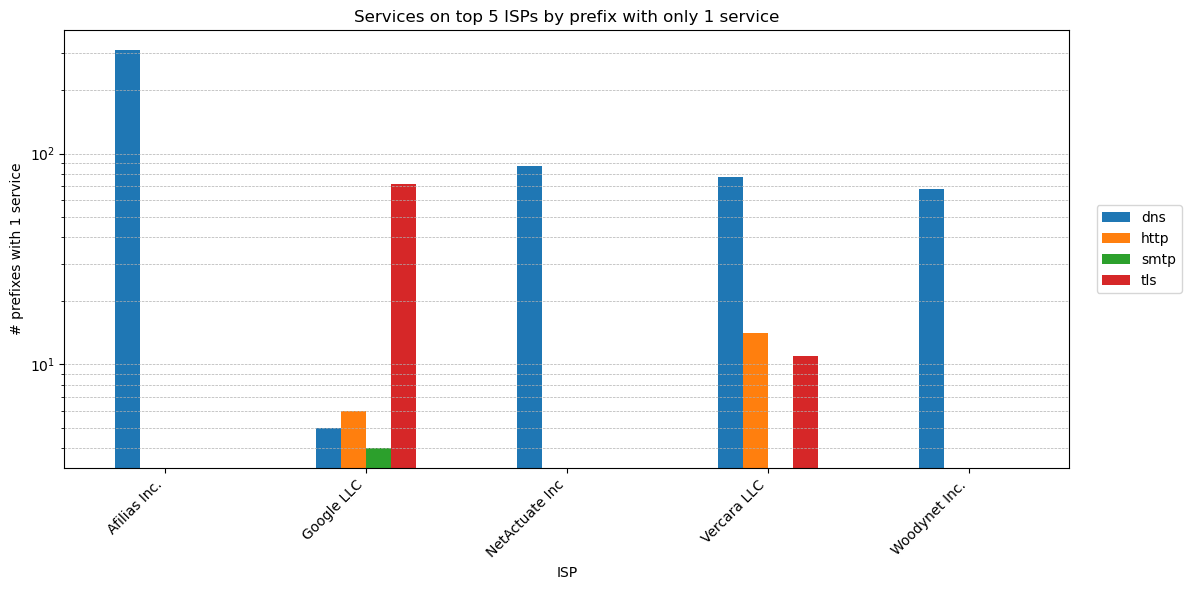

In [129]:
# plot of single purpose AS
plot_df = pdf[pdf["isp_group"] != "Others"].pivot(index="isp_group", columns="service", values="count").fillna(0)

ax = plot_df.plot(kind="bar", figsize=(12,6))

ax.set_ylabel("# prefixes with 1 service")
ax.set_xlabel("ISP")
ax.set_title("Services on top 5 ISPs by prefix with only 1 service")
ax.set_yscale("log")  # optional but useful for skewed data
ax.yaxis.grid(True, which="both", linestyle="--", linewidth=0.5)
leg = ax.legend(
    loc="center left",          # anchor point of legend box
    bbox_to_anchor=(1.02, 0.5), # (x, y) in axes fraction → right side, vertically centered
    frameon=True,
    title=""
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

CDF of prefixes with nr of services

In [119]:
nr_services_pdf = ip2loc_lzr_df.select("prefix", psf.explode_outer("fingerprints").alias("fingerprint")
).filter(
    psf.col("fingerprint") != "unknown"
).groupBy("prefix").agg(psf.collect_set("fingerprint").alias("fingerprints")
).distinct(
).withColumn(
    "nr_services", psf.size(psf.col("fingerprints"))
).groupBy("nr_services").count().toPandas()


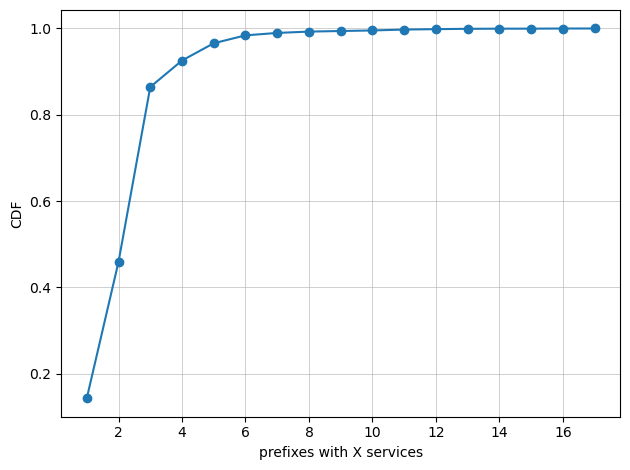

In [128]:
# TODO "what if you plot a second line that excludes management services like SSH and telnet"

cdf_pdf = nr_services_pdf.sort_values("nr_services").copy()
total = cdf_pdf["count"].sum()

cdf_pdf["cum_count"] = cdf_pdf["count"].cumsum()
cdf_pdf["cum_pct"] = cdf_pdf["cum_count"] / total

ax = cdf_pdf.plot(
    x="nr_services",
    y="cum_pct",
    marker="o",
    legend=""
)

#fig, ax = plt.subplots()

#ax.plot(
#    cdf_df["nr_services"],
#    cdf_df["cum_pct"],
#    marker="o"
#)

ax.set_xlabel("prefixes with X services")
ax.set_ylabel("CDF")

ax.grid(True, linewidth=0.6, alpha=0.7)
#ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Services and PoPs

In [ ]:
# TODO

## HRP analysis

In [101]:
# TODO
ip2loc_lzr_df.select("prefix", psf.explode_outer(psf.col("fingerprints")).alias("fingerprint")
).groupBy("fingerprint", "prefix").count().sort("count", ascending=False).show()

+-----------+----------------+-----+
|fingerprint|          prefix|count|
+-----------+----------------+-----+
|    quic-h3| 104.27.118.0/24|  256|
|    quic-h3|140.248.168.0/24|  256|
|    unknown| 104.27.118.0/24|  256|
|    unknown| 212.183.88.0/24|  256|
|    quic-h3| 193.22.229.0/24|  256|
|    unknown|  104.16.34.0/24|  256|
|    unknown|  137.66.56.0/24|  256|
|    unknown|  103.116.7.0/24|  256|
|    unknown| 104.37.179.0/24|  256|
|    quic-h3| 199.232.83.0/24|  256|
|    quic-h3| 104.16.107.0/24|  256|
|    quic-h3| 199.34.229.0/24|  256|
|    unknown|  104.16.30.0/24|  256|
|    quic-h3|  104.19.19.0/24|  256|
|    quic-h3|  146.75.50.0/24|  256|
|    unknown|  104.17.82.0/24|  256|
|    quic-h3|  146.75.27.0/24|  256|
|    unknown|  104.20.10.0/24|  256|
|    quic-h3| 104.17.168.0/24|  256|
|    unknown| 162.159.25.0/24|  256|
+-----------+----------------+-----+
only showing top 20 rows

